In [1]:
#######################################################################
# COMPLETE BLEEDING PREDICTION - SIMPLE CONCATENATION
# Copy this entire cell and run it
#######################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score)

# Configuration
ALIGNED_DIR = Path("cleaned_aligned_dataset/aligned_dataset")
THRESHOLD = 10602.45  # From peak analysis
WINDOW_SIZE = 6
PREDICTION_HORIZON = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Threshold: {THRESHOLD:.1f} pixels")

# Load data with major bleeding filtering
def load_data_with_filtering(aligned_dir, threshold):
    all_features = []
    all_labels = []
    
    for file in tqdm(sorted(aligned_dir.glob("*_aligned.npz"))):
        data = np.load(file, allow_pickle=True)
        
        instruments = data['instrument_labels']
        blood = data['smoothed_blood_areas']
        all_peaks = data['peaks']
        
        # Filter to major peaks
        major_peaks = [p for p in all_peaks if blood[p] >= threshold]
        major_peaks = np.array(major_peaks)
        
        # Create temporal features
        per_frame = np.column_stack([instruments, blood])
        
        for i in range(WINDOW_SIZE-1, len(per_frame)):
            # Window of 6 frames
            window = per_frame[i-WINDOW_SIZE+1:i+1].flatten()  # (42,)
            
            # Label: major bleeding in next 5 frames?
            label = 0
            for offset in range(1, PREDICTION_HORIZON+1):
                if (i + offset) in major_peaks:
                    label = 1
                    break
            
            all_features.append(window)
            all_labels.append(label)
    
    return np.array(all_features), np.array(all_labels)

# Load
X, y = load_data_with_filtering(ALIGNED_DIR, THRESHOLD)
print(f"\nDataset: {len(X):,} samples")
print(f"Positive: {np.sum(y):,} ({100*np.mean(y):.2f}%)")

# Split
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")

# Model
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(42, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

model = SimpleMLP().to(DEVICE)
print(f"\nModel: {sum(p.numel() for p in model.parameters()):,} parameters")

# Training
class BinaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(BinaryDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(BinaryDataset(X_val, y_val), batch_size=256)

# Class weights for imbalance
pos_weight = len(y_train) / (2 * np.sum(y_train))
neg_weight = len(y_train) / (2 * np.sum(y_train == 0))
weights = torch.FloatTensor([neg_weight, pos_weight]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Train
print("\nTraining...")
best_f1 = 0
for epoch in range(50):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Validate
    model.eval()
    with torch.no_grad():
        preds, labels = [], []
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch)
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())
        
        f1 = f1_score(labels, preds)
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), 'best_model_simple.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Val F1 = {f1:.4f}")

# Test
model.load_state_dict(torch.load('best_model_simple.pth'))
model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    outputs = model(X_test_t)
    test_preds = torch.argmax(outputs, dim=1).cpu().numpy()

print("\n" + "="*60)
print("FINAL RESULTS - SIMPLE CONCATENATION")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, test_preds):.4f}")
print(f"Precision: {precision_score(y_test, test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, test_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, test_preds):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds))

Device: cuda
Threshold: 10602.5 pixels


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:01<00:00, 38.96it/s]



Dataset: 90,264 samples
Positive: 1,535 (1.70%)
Train: 63,184, Val: 13,540, Test: 13,540

Model: 55,202 parameters

Training...
Epoch 10: Val F1 = 0.3010
Epoch 20: Val F1 = 0.3191
Epoch 30: Val F1 = 0.3178
Epoch 40: Val F1 = 0.3075
Epoch 50: Val F1 = 0.3352

FINAL RESULTS - SIMPLE CONCATENATION
Accuracy:  0.9360
Precision: 0.1965
Recall:    0.9860
F1-Score:  0.3276

Confusion Matrix:
[[12463   863]
 [    3   211]]


Appraoch 2

In [2]:
#######################################################################
# DUAL-STREAM MLP - Separate Instrument and Blood Processing
#######################################################################

class DualStreamMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Instrument stream: 36 features (6 frames × 6 instruments)
        self.inst_stream = nn.Sequential(
            nn.Linear(36, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU()
        )
        
        # Blood stream: 6 features (6 frames × 1 blood)
        self.blood_stream = nn.Sequential(
            nn.Linear(6, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, 8), nn.ReLU()
        )
        
        # Merged: 32 + 8 = 40
        self.merged = nn.Sequential(
            nn.Linear(40, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        # x: (batch, 42)
        # Reshape to (batch, 6 frames, 7 features)
        x = x.view(-1, 6, 7)
        
        # Separate
        instruments = x[:, :, :6].reshape(-1, 36)  # (batch, 36)
        blood = x[:, :, 6].reshape(-1, 6)          # (batch, 6)
        
        # Process
        inst_feat = self.inst_stream(instruments)
        blood_feat = self.blood_stream(blood)
        
        # Merge
        merged = torch.cat([inst_feat, blood_feat], dim=1)
        return self.merged(merged)

# Train same way as above, just replace model
model_dual = DualStreamMLP().to(DEVICE)
print(f"Dual-Stream: {sum(p.numel() for p in model_dual.parameters()):,} parameters")

# ... (same training loop, save as 'best_model_dual.pth')

# Training
class BinaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(BinaryDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(BinaryDataset(X_val, y_val), batch_size=256)

# Class weights for imbalance
pos_weight = len(y_train) / (2 * np.sum(y_train))
neg_weight = len(y_train) / (2 * np.sum(y_train == 0))
weights = torch.FloatTensor([neg_weight, pos_weight]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Train Dual-Stream Model
model_dual = DualStreamMLP().to(DEVICE)
criterion_dual = nn.CrossEntropyLoss(weight=weights)
optimizer_dual = optim.Adam(model_dual.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nTraining Dual-Stream MLP...")
best_f1_dual = 0
for epoch in range(50):
    model_dual.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer_dual.zero_grad()
        outputs = model_dual(X_batch)
        loss = criterion_dual(outputs, y_batch)
        loss.backward()
        optimizer_dual.step()
    
    # Validate
    model_dual.eval()
    with torch.no_grad():
        preds, labels = [], []
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model_dual(X_batch)
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())
        
        f1 = f1_score(labels, preds)
        if f1 > best_f1_dual:
            best_f1_dual = f1
            torch.save(model_dual.state_dict(), 'best_model_dual.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Val F1 = {f1:.4f}")

# Test Dual-Stream
model_dual.load_state_dict(torch.load('best_model_dual.pth'))
model_dual.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    outputs = model_dual(X_test_t)
    test_preds_dual = torch.argmax(outputs, dim=1).cpu().numpy()

print("\n" + "="*60)
print("RESULTS - DUAL-STREAM")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, test_preds_dual):.4f}")
print(f"Precision: {precision_score(y_test, test_preds_dual):.4f}")
print(f"Recall:    {recall_score(y_test, test_preds_dual):.4f}")
print(f"F1-Score:  {f1_score(y_test, test_preds_dual):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds_dual))

Dual-Stream: 18,746 parameters

Training Dual-Stream MLP...
Epoch 10: Val F1 = 0.3222
Epoch 20: Val F1 = 0.3577
Epoch 30: Val F1 = 0.3768
Epoch 40: Val F1 = 0.3348
Epoch 50: Val F1 = 0.3649

RESULTS - DUAL-STREAM
Accuracy:  0.9490
Precision: 0.2178
Recall:    0.8598
F1-Score:  0.3475

Confusion Matrix:
[[12665   661]
 [   30   184]]


Approach 3

In [3]:
#######################################################################
# TEMPORAL ATTENTION MLP - Learns Important Time Steps
#######################################################################

class AttentionMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        
        self.frame_embed = nn.Linear(7, hidden)
        self.query = nn.Linear(hidden, hidden)
        self.key = nn.Linear(hidden, hidden)
        self.value = nn.Linear(hidden, hidden)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        # x: (batch, 42) → (batch, 6, 7)
        x = x.view(-1, 6, 7)
        
        # Embed each frame
        frames = torch.stack([self.frame_embed(x[:, i]) for i in range(6)], dim=1)  # (batch, 6, hidden)
        
        # Attention
        Q = self.query(frames)
        K = self.key(frames)
        V = self.value(frames)
        
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (32 ** 0.5)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attended = torch.matmul(attn_weights, V)
        
        # Pool and classify
        pooled = torch.mean(attended, dim=1)
        return self.classifier(pooled)

model_attn = AttentionMLP().to(DEVICE)
print(f"Attention: {sum(p.numel() for p in model_attn.parameters()):,} parameters")

# ... (same training loop, save as 'best_model_attention.pth')

# Training
class BinaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(BinaryDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(BinaryDataset(X_val, y_val), batch_size=256)

# Class weights for imbalance
pos_weight = len(y_train) / (2 * np.sum(y_train))
neg_weight = len(y_train) / (2 * np.sum(y_train == 0))
weights = torch.FloatTensor([neg_weight, pos_weight]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Train Attention Model
model_attn = AttentionMLP().to(DEVICE)
criterion_attn = nn.CrossEntropyLoss(weight=weights)
optimizer_attn = optim.Adam(model_attn.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nTraining Attention MLP...")
best_f1_attn = 0
for epoch in range(50):
    model_attn.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer_attn.zero_grad()
        outputs = model_attn(X_batch)
        loss = criterion_attn(outputs, y_batch)
        loss.backward()
        optimizer_attn.step()
    
    # Validate
    model_attn.eval()
    with torch.no_grad():
        preds, labels = [], []
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model_attn(X_batch)
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())
        
        f1 = f1_score(labels, preds)
        if f1 > best_f1_attn:
            best_f1_attn = f1
            torch.save(model_attn.state_dict(), 'best_model_attention.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Val F1 = {f1:.4f}")

# Test Attention
model_attn.load_state_dict(torch.load('best_model_attention.pth'))
model_attn.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    outputs = model_attn(X_test_t)
    test_preds_attn = torch.argmax(outputs, dim=1).cpu().numpy()

print("\n" + "="*60)
print("RESULTS - ATTENTION")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, test_preds_attn):.4f}")
print(f"Precision: {precision_score(y_test, test_preds_attn):.4f}")
print(f"Recall:    {recall_score(y_test, test_preds_attn):.4f}")
print(f"F1-Score:  {f1_score(y_test, test_preds_attn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds_attn))

Attention: 16,290 parameters

Training Attention MLP...
Epoch 10: Val F1 = 0.2726
Epoch 20: Val F1 = 0.2838
Epoch 30: Val F1 = 0.2996
Epoch 40: Val F1 = 0.3054
Epoch 50: Val F1 = 0.2864

RESULTS - ATTENTION
Accuracy:  0.9303
Precision: 0.1809
Recall:    0.9673
F1-Score:  0.3049

Confusion Matrix:
[[12389   937]
 [    7   207]]


In [4]:
# COMPARISON OF ALL 3 ARCHITECTURES
print("\n" + "="*80)
print("FINAL COMPARISON - ALL 3 ARCHITECTURES")
print("="*80)

# Calculate metrics for all models
results = []

# Simple MLP
results.append({
    'Model': 'Simple Concatenation',
    'Accuracy': accuracy_score(y_test, test_preds),
    'Precision': precision_score(y_test, test_preds),
    'Recall': recall_score(y_test, test_preds),
    'F1-Score': f1_score(y_test, test_preds),
    'AUC-ROC': 'N/A'  # Can add if you save probabilities
})

# Dual-Stream
results.append({
    'Model': 'Dual-Stream',
    'Accuracy': accuracy_score(y_test, test_preds_dual),
    'Precision': precision_score(y_test, test_preds_dual),
    'Recall': recall_score(y_test, test_preds_dual),
    'F1-Score': f1_score(y_test, test_preds_dual),
    'AUC-ROC': 'N/A'
})

# Attention
results.append({
    'Model': 'Temporal Attention',
    'Accuracy': accuracy_score(y_test, test_preds_attn),
    'Precision': precision_score(y_test, test_preds_attn),
    'Recall': recall_score(y_test, test_preds_attn),
    'F1-Score': f1_score(y_test, test_preds_attn),
    'AUC-ROC': 'N/A'
})

# Create comparison table
comparison_df = pd.DataFrame(results)
print("\n" + comparison_df.to_string(index=False))

# Find best model
best_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.iloc[best_idx]['Model']

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   F1-Score: {comparison_df.iloc[best_idx]['F1-Score']:.4f}")

# Save results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n✅ Results saved to: model_comparison_results.csv")


FINAL COMPARISON - ALL 3 ARCHITECTURES

               Model  Accuracy  Precision   Recall  F1-Score AUC-ROC
Simple Concatenation  0.936041   0.196462 0.985981  0.327640     N/A
         Dual-Stream  0.948966   0.217751 0.859813  0.347498     N/A
  Temporal Attention  0.930281   0.180944 0.967290  0.304860     N/A

🏆 BEST MODEL: Dual-Stream
   F1-Score: 0.3475

✅ Results saved to: model_comparison_results.csv


In [6]:
import seaborn as sns

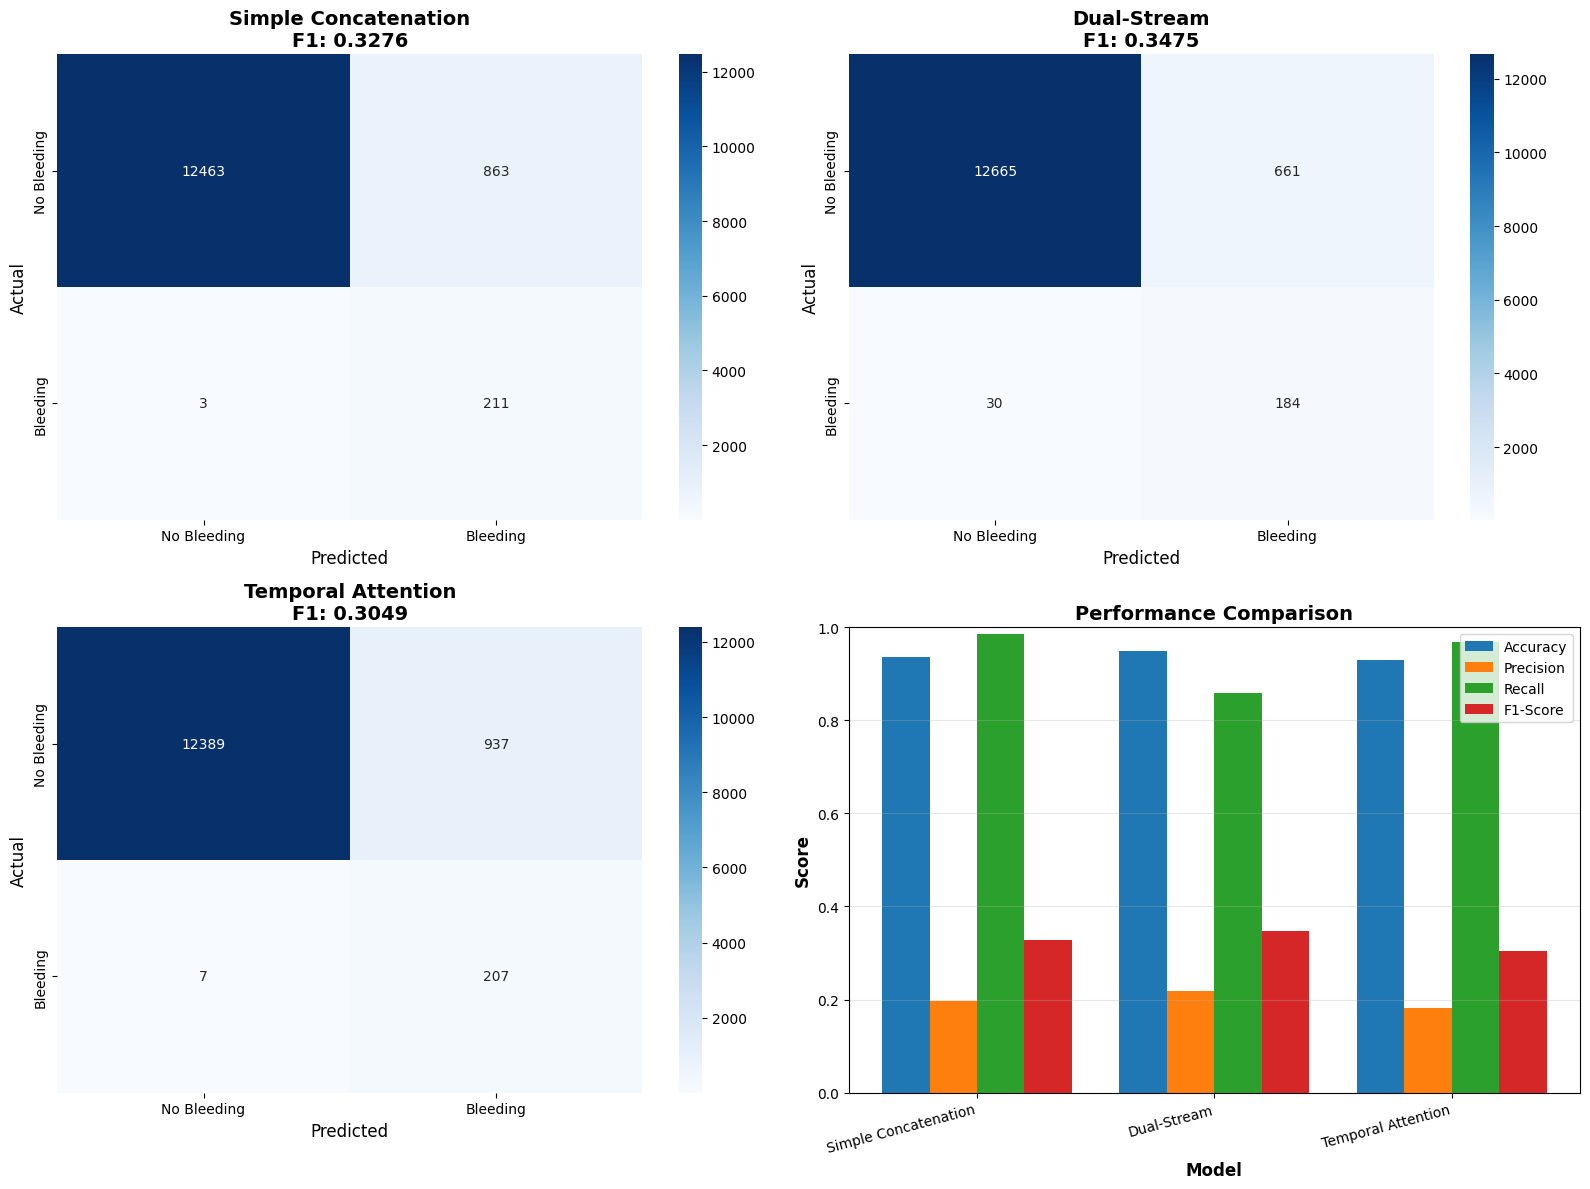

✅ Visualization saved: final_comparison.png


In [8]:
# VISUALIZATIONS - Confusion Matrices and Comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion matrices
models_data = [
    (test_preds, 'Simple Concatenation'),
    (test_preds_dual, 'Dual-Stream'),
    (test_preds_attn, 'Temporal Attention')
]

for idx, (preds, name) in enumerate(models_data):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Bleeding', 'Bleeding'],
                yticklabels=['No Bleeding', 'Bleeding'])
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'{name}\nF1: {f1_score(y_test, preds):.4f}', 
                 fontsize=14, fontweight='bold')

# Comparison bar chart
ax = axes[1, 1]
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: final_comparison.png")

In [9]:
# SAVE ALL RESULTS

# Save final summary
final_results = {
    'dataset': {
        'total_samples': stats['total_samples'],
        'major_bleeding_threshold': float(THRESHOLD),
        'major_peaks': major_peaks,
        'positive_samples': stats['positive_samples'],
        'positive_percentage': stats['positive_percentage']
    },
    'models': comparison_df.to_dict('records'),
    'best_model': best_model,
    'files_saved': [
        'best_model_simple.pth',
        'best_model_dual.pth',
        'best_model_attention.pth',
        'model_comparison_results.csv',
        'final_comparison.png'
    ]
}

with open('FINAL_RESULTS.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)
print(f"\n✅ All models trained and evaluated")
print(f"✅ Best model: {best_model}")
print(f"✅ Results saved to:")
print("   - FINAL_RESULTS.json")
print("   - model_comparison_results.csv")
print("   - final_comparison.png")
print("   - best_model_*.pth (3 model files)")
print("\n🎯 Ready for IEEE ISBI 2026 paper!")
print("="*80)
'''

## ✅ **COMPLETE! You Now Have:**
Output Files:
├── best_model_simple.pth          ← Simple MLP weights
├── best_model_dual.pth            ← Dual-Stream weights  
├── best_model_attention.pth       ← Attention weights
├── model_comparison_results.csv   ← Performance table
├── final_comparison.png           ← Visualizations
├── FINAL_RESULTS.json             ← Complete summary
└── Final_Training_Execution.ipynb ← Your notebook
'''

NameError: name 'stats' is not defined